# 1 — Understanding the data

Before anything is modelled, the data has to be understood and its problems stated
out loud. Three things decided the whole design of this project, and all three are
visible in this notebook:

1. how much history actually exists per store and department,
2. where that history is broken,
3. which columns are missing because nothing happened, versus missing because
   nothing was recorded.

The source is a weekly sales extract from a 45-store retail chain, split across four
files: sales, store attributes, and a set of external and promotional signals.

In [1]:
import sys
from pathlib import Path

# Notebooks live one level below the project root; the shared code lives in src/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from src import config, data, evaluate, features, models, plots

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

## The raw files, as delivered

`stores.csv` needs the python parser: it arrives with carriage-return-only line
endings, and the default reader collapses it into a single row. Small detail, but a
silent one — worth catching here rather than wondering later why every store looks
the same.

In [2]:
raw = data.load_raw()

for name, frame in raw.items():
    print(f"{name:>10}: {frame.shape[0]:>7,} rows x {frame.shape[1]} columns")

     train: 421,570 rows x 5 columns
  features:   8,190 rows x 12 columns
    stores:      45 rows x 3 columns


In [3]:
raw["train"].head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


## Data quality report

This is the check that runs before every pipeline execution. It is not decoration:
each line below turned into a design decision further down.

In [4]:
profile = data.profile_raw(raw)
profile

,check,value
0,rows,421570
1,stores,45
2,departments,81
3,store_dept_series,3331
4,weeks_covered,143
5,first_week,2010-02-05
6,last_week,2012-10-26
7,duplicate_keys,0
8,series_with_full_history,2660
9,series_under_52_weeks,340


### What this tells us

**The history is short.** Roughly two and a half years, covering 143 weeks. That is
barely two complete annual cycles, which is the minimum for learning a yearly
seasonal pattern at all and well short of comfortable. Every claim this project
makes should be read with that in mind.

**Most series are complete, but not all.** Of the 3,331 store-department
combinations, about four fifths have the full history. Several hundred have weeks
missing *inside* their span — a department that recorded no sales for a stretch and
then resumed.

This second point is the one that matters most, and it is easy to get wrong. If rows
are simply shifted down to build a "last year's sales" feature, a series with gaps
gets a value from the wrong week entirely, and nothing in the code complains. Every
series is therefore placed on a continuous weekly calendar first, with missing weeks
held open as blanks rather than filled with invented zeros.

**A small number of weeks have negative sales.** About 0.3% of rows — returns
exceeding sales in that department that week. These are real events and are kept as
they are. They do, however, break the standard percentage-error metric, which is why
the evaluation uses a weighted variant.

In [5]:
train = raw["train"]
negative = train[train["Weekly_Sales"] < 0]

print(f"negative-sales weeks: {len(negative):,} ({len(negative) / len(train):.2%})")
print(f"most negative week:   {train['Weekly_Sales'].min():,.2f}")
print(f"zero-sales weeks:     {(train['Weekly_Sales'] == 0).sum():,}")

negative-sales weeks: 1,285 (0.30%)
most negative week:   -4,988.94
zero-sales weeks:     73


## Promotions were not always tracked

The five markdown columns are empty for the first two thirds of the history. That is
not a data-quality failure — promotional tracking simply began partway through, in
November 2011.

The distinction matters. Treating those blanks as "unknown" and imputing them would
teach the model that promotional activity jumped when in fact only the recording did.
They are set to zero, and a separate flag marks which era each week belongs to, so
the model can tell the two apart.

In [6]:
features_raw = raw["features"]
markdown_cols = config.MARKDOWN_COLS

first_tracked = features_raw.loc[features_raw[markdown_cols].notna().any(axis=1), "Date"].min()
print(f"first week with any promotion recorded: {first_tracked.date()}")

after = features_raw[features_raw["Date"] >= first_tracked]
(after[markdown_cols].isna().mean().rename("missing share after tracking began").to_frame())

first week with any promotion recorded: 2011-11-11


,missing share after tracking began
MarkDown1,0.004444
MarkDown2,0.278765
MarkDown3,0.107901
MarkDown4,0.144691
MarkDown5,0.000000


## Building the analysis panel

One row per store, department and week, on an unbroken weekly calendar, with store
attributes and external signals joined on.

In [7]:
panel = data.build_panel(raw)

print(f"{len(panel):,} rows  ({(~panel['HasSales']).sum():,} are calendar placeholders "
      f"with no recorded sales)")
panel.head()

449,237 rows  (27,667 are calendar placeholders with no recorded sales)


,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,MarkdownTotal,MarkdownsTracked,CPI,Unemployment,IsHoliday,HasSales
0,1,1,2010-02-05,24924.50,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,0.0,0,211.096358,8.106,False,True
1,1,1,2010-02-12,46039.49,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,0.0,0,211.242170,8.106,True,True
2,1,1,2010-02-19,41595.55,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,0.0,0,211.289143,8.106,False,True
3,1,1,2010-02-26,19403.54,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,0.0,0,211.319643,8.106,False,True
4,1,1,2010-03-05,21827.90,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,0.0,0,211.350143,8.106,False,True


## The pattern being forecast

Two charts are enough to explain the commercial problem to anyone.

findfont: Failed to find font weight 600, now using 700.


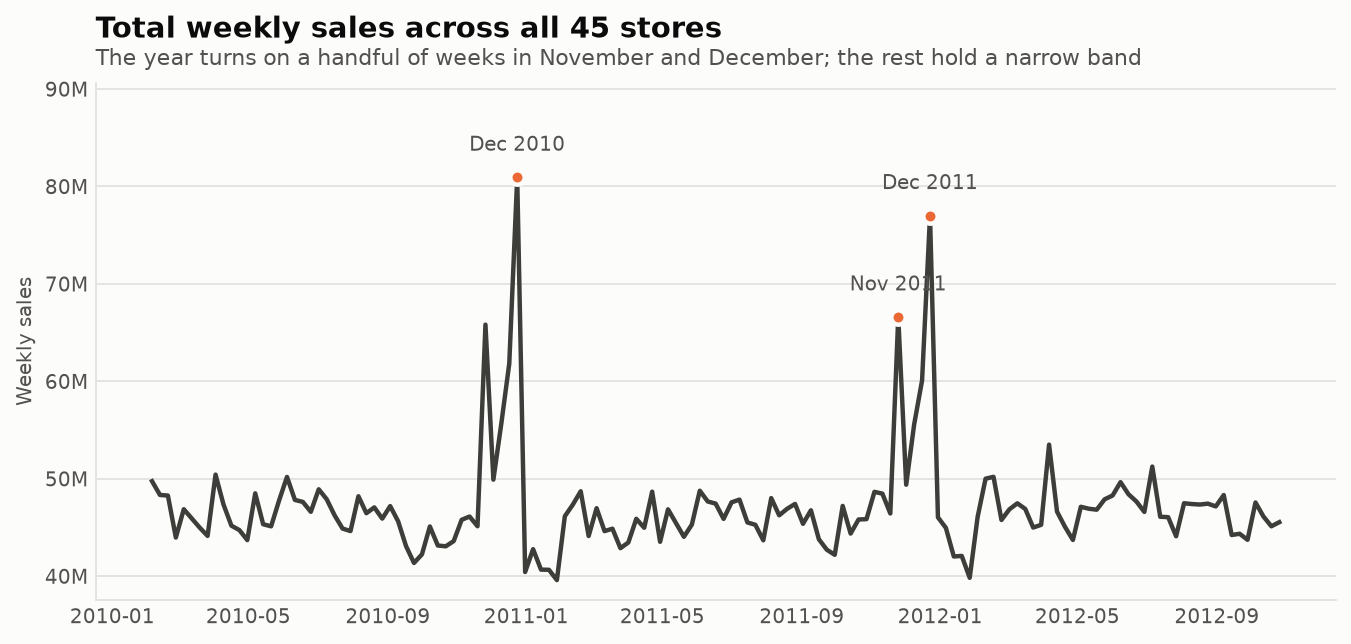

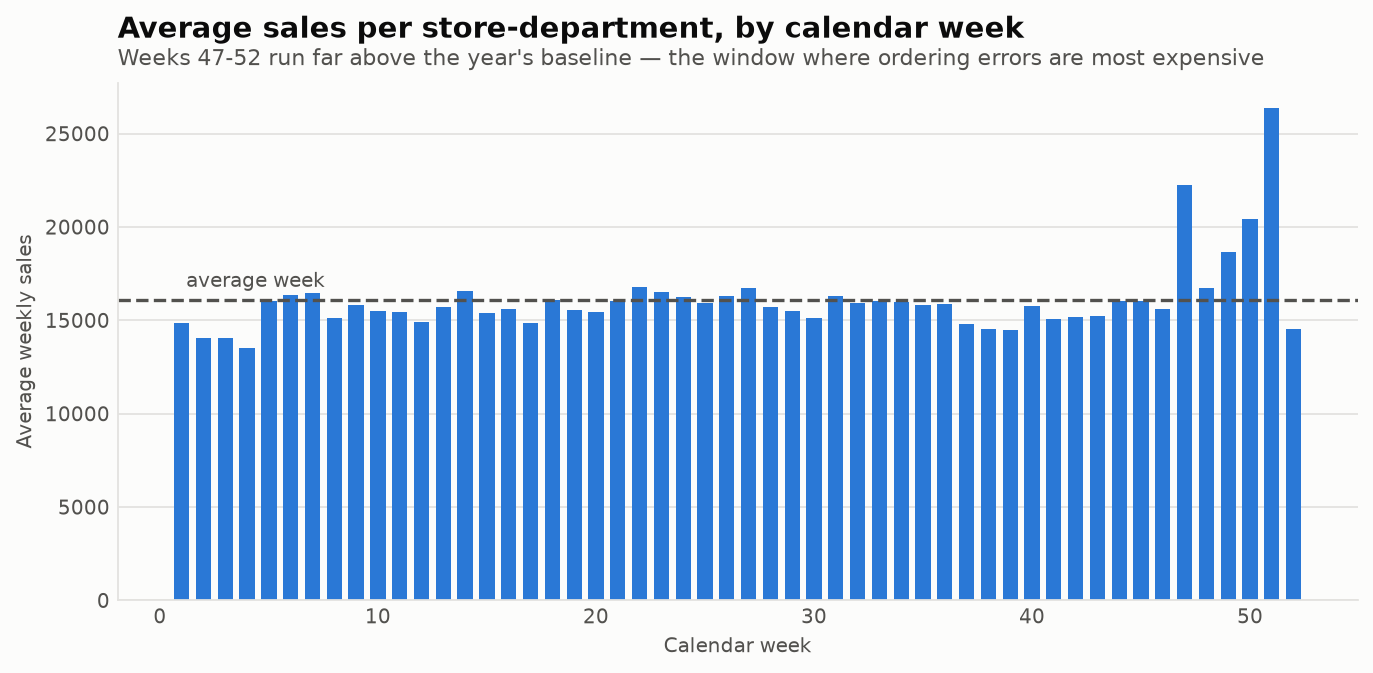

In [8]:
plots.plot_sales_history(panel)
plots.plot_seasonal_profile(panel)

from IPython.display import Image, display

display(Image(str(config.FIGURES_DIR / "01_sales_history.png")))
display(Image(str(config.FIGURES_DIR / "02_seasonal_profile.png")))

The shape of the year is the whole point. Ordinary weeks sit in a fairly narrow band;
a handful of weeks in November and December run far above it. Those weeks are also
where a planning mistake is most expensive in both directions — an empty shelf during
the only weeks that matter, or a warehouse of stock nobody wants in January.

A planner working without a forecast typically handles this by repeating last year:
order for week 47 what sold in week 47 last year. That is a genuinely reasonable
method, and it is the benchmark the model has to beat in the next notebook.

## Store formats differ

The chain runs three store formats, of very different sizes. Any credible result has
to hold across all three rather than being an average that hides a weak segment.

In [9]:
(raw["stores"]
 .groupby("Type")
 .agg(Stores=("Store", "count"),
      MedianSize=("Size", "median"),
      SmallestSize=("Size", "min"),
      LargestSize=("Size", "max"))
 .round(0))

,Stores,MedianSize,SmallestSize,LargestSize
Type,,,,
A,22,202406.0,39690,219622
B,17,114533.0,34875,140167
C,6,39910.0,39690,42988


## What carries into the modelling

- Series sit on a continuous weekly calendar, so history features refer to the week
  they claim to.
- Weeks with no recorded sales stay blank; they are never scored and never trained on.
- Negative sales are kept; the metric is chosen to cope with them.
- Promotion columns are zero-filled with an era flag, not imputed.
- Two and a half years of history is a real constraint and is stated in the results,
  not buried.